# Этап 1

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from keras.datasets import imdb

## Загрузка данных

In [ ]:
num_words = 10000
max_len = 200
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)
print(f'Тренировочные данные: {len(x_train)} последовательностей')
print(f'Тестовые данные: {len(x_test)} последовательностей')

Тренировочные данные: 25000 последовательностей
Тестовые данные: 25000 последовательностей


## Подготовка данных для передачи в нейросеть

In [ ]:
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

## Построение модели

In [ ]:
model = keras.Sequential([
    layers.Embedding(
        input_dim=num_words,
        output_dim=64,
    ),

    layers.LSTM(
        units=32,
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    layers.LSTM(
        units=64,
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    layers.LSTM(
        units=32,
        return_sequences=False,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    layers.Dense(1, activation='sigmoid')
])

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=10, monitor='val_loss', restore_best_weights=True, min_delta=0.001, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
]

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 200, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 200, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,069,093 (7.89 MB)

 Trainable params: 689,697 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,379,396 (5.26 MB)

## Обучение модели

In [ ]:
history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=5,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 271s 866ms/step - accuracy: 0.8123 - loss: 0.4296 - val_accuracy: 0.8218 - val_loss: 0.4067 - learning_rate: 0.0010
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 230s 734ms/step - accuracy: 0.8728 - loss: 0.3167 - val_accuracy: 0.8348 - val_loss: 0.3847 - learning_rate: 0.0010
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 210s 671ms/step - accuracy: 0.8975 - loss: 0.2659 - val_accuracy: 0.8558 - val_loss: 0.3532 - learning_rate: 0.0010
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 206s 660ms/step - accuracy: 0.9088 - loss: 0.2487 - val_accuracy: 0.8500 - val_loss: 0.3588 - learning_rate: 0.0010
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 209s 669ms/step - accuracy: 0.9031 - loss: 0.2564 - val_accuracy: 0.8574 - val_loss: 0.3707 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.


## Построение графиков

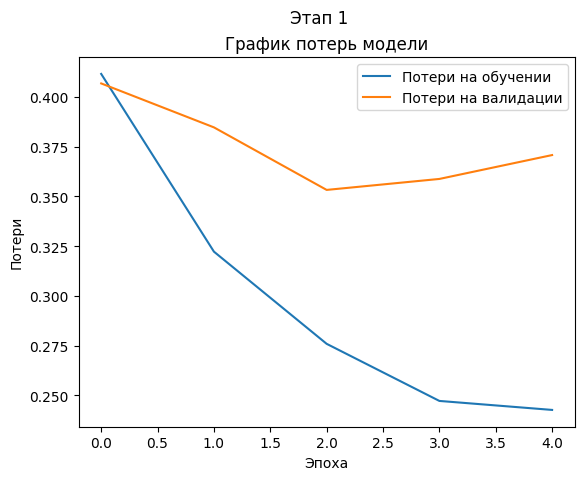

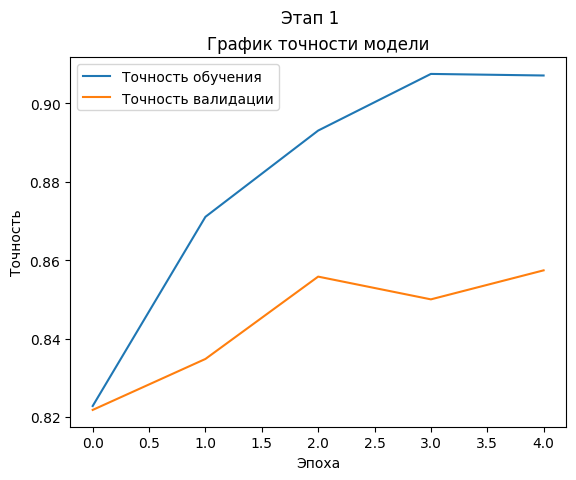

In [ ]:
import matplotlib.pyplot as plt

plt.figure().suptitle('Этап 1')
plt.plot(history.history['loss'], label='Потери на обучении')
plt.plot(history.history['val_loss'], label='Потери на валидации')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.title('График потерь модели')
plt.legend()

plt.figure().suptitle('Этап 1')
plt.plot(history.history['accuracy'], label='Точность обучения')
plt.plot(history.history['val_accuracy'], label='Точность валидации')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.title('График точности модели')
plt.legend()

plt.show()

## Оценка на тестовых данных

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Точность на тесте: {test_accuracy}')
print(f'Потери на тесте: {test_loss}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 95ms/step - accuracy: 0.8477 - loss: 0.3726
Точность на тесте: 0.8480799794197083
Потери на тесте: 0.37096673250198364


## Одномерная сверточная сеть

In [ ]:
base_model = keras.Sequential([
    layers.Embedding(
        input_dim=num_words,
        output_dim=128,
    ),

    layers.Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu',
    ),
    layers.MaxPooling1D(
        pool_size=2
    ),
    layers.Dropout(0.3),

    layers.Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
    ),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    layers.Conv1D(
        filters=32,
        kernel_size=3,
        activation='relu',
    ),
    layers.GlobalMaxPooling1D(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
base_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
base_model.build(input_shape=(None, max_len))
base_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 196, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 98, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 98, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 96, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 46, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,395,041 (5.32 MB)

 Trainable params: 1,395,041 (5.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = base_model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=5,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 217ms/step - accuracy: 0.5273 - loss: 0.6784 - val_accuracy: 0.8320 - val_loss: 0.4057 - learning_rate: 0.0010
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 215ms/step - accuracy: 0.8527 - loss: 0.3635 - val_accuracy: 0.8448 - val_loss: 0.3693 - learning_rate: 0.0010
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 214ms/step - accuracy: 0.9167 - loss: 0.2268 - val_accuracy: 0.8562 - val_loss: 0.3444 - learning_rate: 0.0010
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 212ms/step - accuracy: 0.9396 - loss: 0.1696 - val_accuracy: 0.8510 - val_loss: 0.3548 - learning_rate: 0.0010
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 218ms/step - accuracy: 0.9620 - loss: 0.1130 - val_accuracy: 0.8432 - val_loss: 0.4085 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.


In [ ]:
test_loss, test_accuracy = base_model.evaluate(x_test, y_test)
print(f'Точность на тесте: {test_accuracy}')
print(f'Потери на тесте: {test_loss}')

782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.8540 - loss: 0.3440
Точность на тесте: 0.8511999845504761
Потери на тесте: 0.34601300954818726


**Итоги:**

Рекурентная модель:

Точность на тесте: 0.8481;
Потери на тесте: 0.371

Сверточная модель:

Точность на тесте: 0.8512;
Потери на тесте: 0.346

# Этап 2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Загрузка данных

In [ ]:
url = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip'
df = pd.read_csv(url, compression='zip')

In [ ]:
print(f'Размер датасета: {df.shape}')
print(f'Колонки: {df.columns.tolist()}')

Размер датасета: (420551, 15)
Колонки: ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


## Подготовка данных

In [ ]:
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
timestamps = df['Date Time'].values
df = df.drop('Date Time', axis=1)

In [ ]:
sequence_length = 240
delay = 24
step = sequence_length + delay

hourly_indices = np.arange(0, len(df), 6)
data_hourly = df.iloc[hourly_indices].values
timestamps_hourly = timestamps[hourly_indices]

sequences = []
targets = []

temperature_idx = df.columns.get_loc('T (degC)')

for i in range(0, len(data_hourly) - sequence_length - delay, step):
    sequences.append(data_hourly[i:i + sequence_length])
    targets.append(data_hourly[i + sequence_length + delay, temperature_idx])

sequences = np.array(sequences)
targets = np.array(targets)

In [ ]:
n_features = sequences.shape[2]

sequences_scaled = np.zeros_like(sequences)
for feature_idx in range(n_features):
    scaler = StandardScaler()
    feature_data = sequences[:, :, feature_idx].reshape(-1, 1)
    feature_scaled = scaler.fit_transform(feature_data)
    sequences_scaled[:, :, feature_idx] = feature_scaled.reshape(
        sequences.shape[0], sequences.shape[1]
    )

target_scaler = StandardScaler()
targets_scaled = target_scaler.fit_transform(targets.reshape(-1, 1)).flatten()

X_train, X_test, y_train, y_test = train_test_split(
    sequences_scaled, targets_scaled,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

## Построение модели

In [ ]:
n_features = X_train.shape[2]

model = keras.Sequential([
    layers.Input(shape=(sequence_length, n_features), name='input_layer'),

    layers.GRU(32,
               return_sequences=True,
               dropout=0.2,
               recurrent_dropout=0.2,
               name='gru_1'),

    layers.GRU(64,
               return_sequences=True,
               dropout=0.2,
               recurrent_dropout=0.2,
               name='gru_2'),

    layers.GRU(64,
               return_sequences=True,
               dropout=0.2,
               recurrent_dropout=0.2,
               name='gru_3'),

    layers.GRU(32,
               return_sequences=False,
               dropout=0.2,
               recurrent_dropout=0.2,
               name='gru_4'),

    layers.Dense(1, name='output')
])

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 240, 32)        │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 240, 64)        │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 240, 64)        │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,825 (225.88 KB)

 Trainable params: 57,825 (225.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=10, monitor='val_loss', restore_best_weights=True, min_delta=0.001, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
]

## Обучение модели

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - loss: 0.7987 - mae: 0.6955 - val_loss: 0.5789 - val_mae: 0.6104 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - loss: 0.2930 - mae: 0.4012 - val_loss: 0.5039 - val_mae: 0.5774 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 802ms/step - loss: 0.2423 - mae: 0.3810 - val_loss: 0.5294 - val_mae: 0.5989 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 876ms/step - loss: 0.2284 - mae: 0.3645 - val_loss: 0.5273 - val_mae: 0.5923 - learning_rate: 0.0010
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 845ms/step - loss: 0.2577 - mae: 0.3675 - val_loss: 0.5017 - val_mae: 0.5757 - learning_rate: 0.0010
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - loss: 0.2213 - mae: 0.3544 - val_loss: 0.5082 - val_mae: 0.5744 - learning_rate: 0.0010
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 782ms/step - loss: 0.1887 - mae: 0.3112 - val_loss: 0.4820 - val_mae: 0.5609 - learning_rate: 0.0010
Epoch 8/30
6/6 ━━━━━━━━━━━━

## Построение графиков

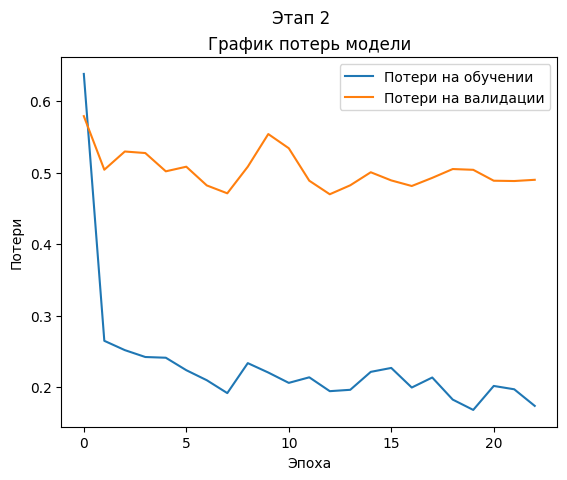

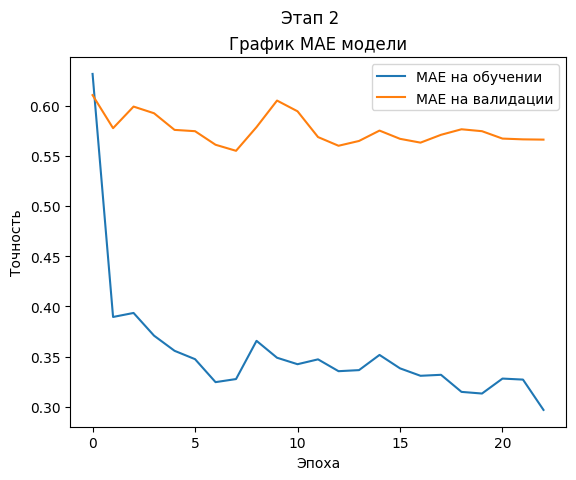

In [ ]:
plt.figure().suptitle('Этап 2')
plt.plot(history.history['loss'], label='Потери на обучении')
plt.plot(history.history['val_loss'], label='Потери на валидации')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.title('График потерь модели')
plt.legend()

plt.figure().suptitle('Этап 2')
plt.plot(history.history['mae'], label='MAE на обучении')
plt.plot(history.history['val_mae'], label='MAE на валидации')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.title('График MAE модели')
plt.legend()

plt.show()

## Оценка на тестовых данных

In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f'MAE на тесте: {test_mae}')
print(f'Потери на тесте: {test_loss}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - loss: 0.6654 - mae: 0.6710
MAE на тесте: 0.683295488357544
Потери на тесте: 0.6782820224761963


In [ ]:
y_pred_scaled = model.predict(X_test, verbose=0).flatten()
y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae_celsius = np.mean(np.abs(y_pred - y_test_original))
print(f'MAE на тесте в градусах Цельсия: {mae_celsius:.2f}°C')

MAE на тесте в градусах Цельсия: 5.55°C


## Комбинированная сеть

In [ ]:
base_model = keras.Sequential([
    layers.Input(shape=(sequence_length, n_features), name='input_layer'),

    layers.Conv1D(
            filters=32,
            kernel_size=3,
            activation='relu',
            name='conv1d_1'
        ),
        layers.BatchNormalization(name='batch_norm_1'),
        layers.MaxPooling1D(pool_size=2, name='max_pool_1'),

        layers.Conv1D(
            filters=64,
            kernel_size=5,
            activation='relu',
            name='conv1d_2'
        ),
        layers.BatchNormalization(name='batch_norm_2'),
        layers.MaxPooling1D(pool_size=2, name='max_pool_2'),

        layers.Conv1D(
            filters=64,
            kernel_size=7,
            strides=1,
            padding='same',
            activation='relu',
            name='conv1d_3'
        ),
        layers.BatchNormalization(name='batch_norm_3'),
        layers.MaxPooling1D(pool_size=2, name='max_pool_3'),

    layers.GRU(32,
               return_sequences=True,
               dropout=0.2,
               recurrent_dropout=0.2,
               name='gru_1'),

    layers.GRU(64,
               return_sequences=True,
               dropout=0.2,
               recurrent_dropout=0.2,
               name='gru_2'),

    layers.GRU(64,
               return_sequences=True,
               dropout=0.2,
               recurrent_dropout=0.2,
               name='gru_3'),

    layers.GRU(32,
               return_sequences=False,
               dropout=0.2,
               recurrent_dropout=0.2,
               name='gru_4'),

    layers.Dense(1, name='output')
])

In [ ]:
base_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [ ]:
base_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 238, 32)        │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 238, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling1D)       │ (None, 119, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 115, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 115, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling1D)       │ (None, 57, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 57, 64)         │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_3                    │ (None, 57, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_3 (MaxPooling1D)       │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 28, 32)         │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 28, 64)         │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 28, 64)         │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,681 (405.00 KB)

 Trainable params: 103,361 (403.75 KB)

 Non-trainable params: 320 (1.25 KB)

In [ ]:
history = base_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 525ms/step - loss: 0.5652 - mae: 0.5850 - val_loss: 1.0039 - val_mae: 0.7929 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - loss: 0.3407 - mae: 0.4528 - val_loss: 1.0655 - val_mae: 0.8350 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - loss: 0.3943 - mae: 0.4767 - val_loss: 0.9705 - val_mae: 0.7984 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - loss: 0.2487 - mae: 0.3870 - val_loss: 0.8713 - val_mae: 0.7590 - learning_rate: 0.0010
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 0.3069 - mae: 0.4291 - val_loss: 0.8818 - val_mae: 0.7731 - learning_rate: 0.0010
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - loss: 0.2355 - mae: 0.3731 - val_loss: 0.9301 - val_mae: 0.7959 - learning_rate: 0.0010
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - loss: 0.2534 - mae: 0.3908 - val_loss: 0.9310 - val_mae: 0.8154 - learning_rate: 0.0010
Epoch 8/30
6/6 ━━━━

In [ ]:
test_loss, test_mae = base_model.evaluate(X_test, y_test)
print(f'MAE на тесте: {test_mae}')
print(f'Потери на тесте: {test_loss}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.5960 - mae: 0.6059
MAE на тесте: 0.6182389259338379
Потери на тесте: 0.612343966960907


In [ ]:
y_pred_scaled = base_model.predict(X_test, verbose=0).flatten()
y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae_celsius = np.mean(np.abs(y_pred - y_test_original))
print(f'MAE на тесте в градусах Цельсия: {mae_celsius:.2f}°C')

MAE на тесте в градусах Цельсия: 5.02°C


**Итоги:**

Рекурентная модель:

MAE на тесте: 0.683295488357544
Потери на тесте: 0.6782820224761963
MAE на тесте в градусах Цельсия: 5.55°C

Комбинированная модель:

MAE на тесте: 0.6182389259338379
Потери на тесте: 0.612343966960907
MAE на тесте в градусах Цельсия: 5.02°C